In [9]:
import sys, os, json, torch, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

# Reproducibility setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORD_MAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'

VAL_IMAGES_DIR = '../dataset/val2014'
DATASET_JSON = '../dataset/caption_datasets/dataset_coco.json'

IMAGES_PER_CATEGORY = 100 
BEAM_SIZE = 3

RAW_CATEGORIES = {
    "People": {"man", "woman", "person", "boy", "girl", "people", "baby", "men", "women"},
    "Animals": {"dog", "cat", "horse", "elephant", "bird", "bear", "zebra", "giraffe", "cow", "sheep"},
    "Vehicles": {"car", "bus", "train", "truck", "motorcycle", "airplane", "boat", "bicycle", "plane"},
    "Food": {"pizza", "cake", "apple", "banana", "food", "sandwich", "broccoli", "carrot", "donut", "meal"},
    "Indoor": {"kitchen", "bedroom", "bathroom", "table", "chair", "bed", "couch", "sofa", "toilet", "tv", "desk"}
}

# Load word map
with open(WORD_MAP_PATH, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

# Vocabulary validation (Filter out target words missing from the model's vocabulary)
CATEGORIES = {}
print("--- Keyword Validation against Word Map ---")
for cat, words in RAW_CATEGORIES.items():
    valid_words = {w for w in words if w in word_map}
    CATEGORIES[cat] = valid_words
    dropped = words - valid_words
    if dropped:
        print(f"[{cat}] Dropped (not in vocab): {dropped}")
    else:
        print(f"[{cat}] All keywords valid.")

checkpoint = torch.load(MODEL_PATH, map_location=str(DEVICE), weights_only=False)
decoder, encoder = checkpoint['decoder'].to(DEVICE).eval(), checkpoint['encoder'].to(DEVICE).eval()

--- Keyword Validation against Word Map ---
[People] All keywords valid.
[Animals] All keywords valid.
[Vehicles] All keywords valid.
[Food] All keywords valid.
[Indoor] All keywords valid.


In [10]:
with open(DATASET_JSON, 'r') as j:
    test_images = [img for img in json.load(j)['images'] if img['split'] == 'test']

candidates = {cat: {} for cat in CATEGORIES.keys()}

# Independent candidate aggregation (images may belong to multiple categories)
for img in test_images:
    filename = img['filename']
    filepath = os.path.join(VAL_IMAGES_DIR, filename)
    if not os.path.exists(filepath): 
        continue
        
    ref_tokens = set(word for sentence in img['sentences'] for word in sentence['tokens'])
    
    for cat_name, keywords in CATEGORIES.items():
        if ref_tokens.intersection(keywords):
            candidates[cat_name][filename] = [c['tokens'] for c in img['sentences']]

category_data = {}
print("\n--- Sampling Distribution ---")
for cat, imgs in candidates.items():
    if len(imgs) < IMAGES_PER_CATEGORY:
        print(f"WARNING: Only {len(imgs)} candidates for {cat}. Using all.")
        sampled_keys = list(imgs.keys())
    else:
        sampled_keys = random.sample(list(imgs.keys()), IMAGES_PER_CATEGORY)
        
    category_data[cat] = {k: imgs[k] for k in sampled_keys}
    print(f"{cat}: Sampled {len(category_data[cat])} images (Pool: {len(imgs)}).")


--- Sampling Distribution ---
People: Sampled 100 images (Pool: 2306).
Animals: Sampled 100 images (Pool: 919).
Vehicles: Sampled 100 images (Pool: 768).
Food: Sampled 100 images (Pool: 664).
Indoor: Sampled 100 images (Pool: 1305).


In [11]:
# Bootstrapping for BLEU-4 statistical significance
def bootstrap_bleu(actual_refs, actual_hyps, n_iterations=1000):
    scores = []
    n = len(actual_hyps)
    for _ in range(n_iterations):
        indices = np.random.choice(n, n, replace=True)
        b_refs = [actual_refs[i] for i in indices]
        b_hyps = [actual_hyps[i] for i in indices]
        scores.append(corpus_bleu(b_refs, b_hyps, weights=(0.25, 0.25, 0.25, 0.25)))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

category_metrics = {}

for cat_name, references_dict in category_data.items():
    actual_refs, actual_hyps = [], []
    hit_count = 0
    cat_keywords = CATEGORIES[cat_name]
    
    for filename, refs in tqdm(references_dict.items(), desc=f"Evaluating {cat_name}"):
        filepath = os.path.join(VAL_IMAGES_DIR, filename)
        seq, _ = caption_image_beam_search(encoder, decoder, filepath, word_map, BEAM_SIZE)
        hypothesis = [rev_word_map[w] for w in seq if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        
        actual_refs.append(refs)
        actual_hyps.append(hypothesis)
        
        # Strict Hit Rate (Validate generated word against image-specific references)
        image_specific_keywords = set(w for r in refs for w in r).intersection(cat_keywords)
        if set(hypothesis).intersection(image_specific_keywords):
            hit_count += 1
            
    bleu4 = corpus_bleu(actual_refs, actual_hyps, weights=(0.25, 0.25, 0.25, 0.25))
    ci_lower, ci_upper = bootstrap_bleu(actual_refs, actual_hyps)
    
    category_metrics[cat_name] = {
        "BLEU4": bleu4,
        "CI_Lower": ci_lower,
        "CI_Upper": ci_upper,
        "HitRate": hit_count / len(references_dict)
    }

Evaluating Indoor: 100%|██████████| 100/100 [00:03<00:00, 30.50it/s]


,Category,BLEU4,CI_Lower,CI_Upper,HitRate,Error_Lower,Error_Upper
0,People,0.319717,0.275037,0.363193,0.61,0.044679,0.043476
1,Animals,0.331153,0.275891,0.386065,0.72,0.055262,0.054912
2,Vehicles,0.256659,0.202345,0.311839,0.64,0.054315,0.055180
3,Food,0.326060,0.272448,0.376677,0.56,0.053612,0.050617
4,Indoor,0.355484,0.311374,0.404871,0.58,0.044110,0.049387


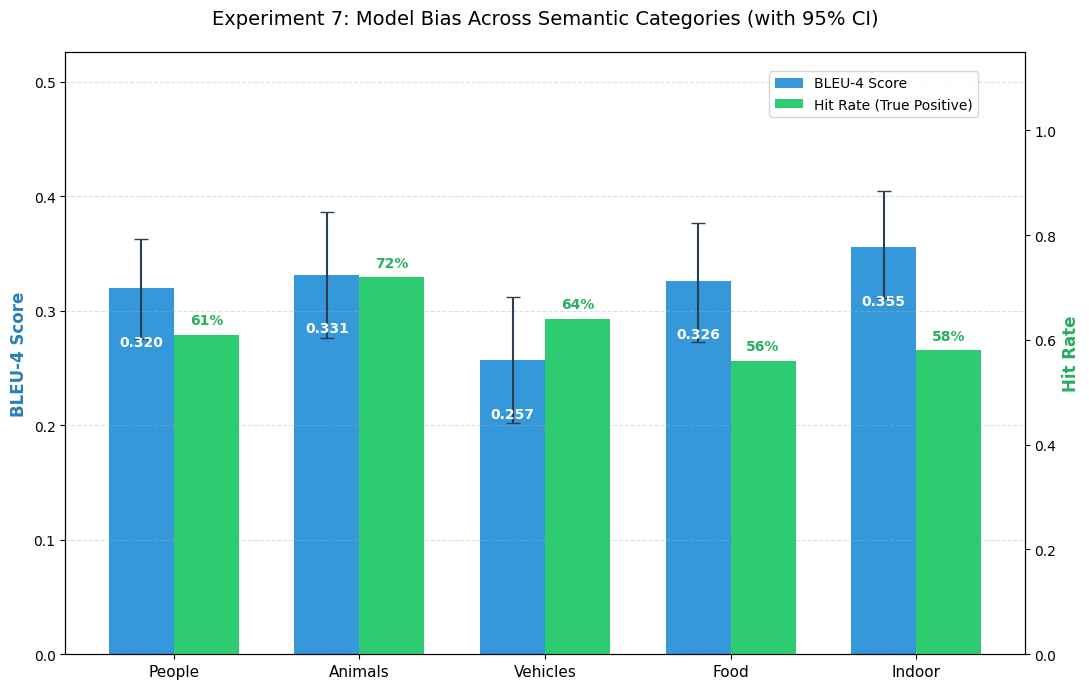

In [12]:
df_metrics = pd.DataFrame.from_dict(category_metrics, orient='index').reset_index()
df_metrics.rename(columns={'index': 'Category'}, inplace=True)
df_metrics['Error_Lower'] = df_metrics['BLEU4'] - df_metrics['CI_Lower']
df_metrics['Error_Upper'] = df_metrics['CI_Upper'] - df_metrics['BLEU4']
display(df_metrics)

fig, ax1 = plt.subplots(figsize=(11, 7))
x = np.arange(len(df_metrics['Category']))
width = 0.35

# BLEU-4 with Confidence Intervals (95% CI)
bars1 = ax1.bar(x - width/2, df_metrics['BLEU4'], width, color='#3498db', label='BLEU-4 Score',
                yerr=[df_metrics['Error_Lower'], df_metrics['Error_Upper']], capsize=5, ecolor='#2c3e50')
ax1.set_ylabel('BLEU-4 Score', fontsize=12, color='#2980b9', fontweight='bold')
ax1.set_ylim(0, max(df_metrics['CI_Upper']) * 1.3)

# Hit Rate (Secondary Axis)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, df_metrics['HitRate'], width, color='#2ecc71', label='Hit Rate (True Positive)')
ax2.set_ylabel('Hit Rate', fontsize=12, color='#27ae60', fontweight='bold')
ax2.set_ylim(0, 1.15)

ax1.set_xticks(x)
ax1.set_xticklabels(df_metrics['Category'], fontsize=11)
plt.title('Experiment 7: Model Bias Across Semantic Categories (with 95% CI)', fontsize=14, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Value annotations on bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval - 0.05, f"{yval:.3f}", ha='center', color='white', fontweight='bold')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval*100:.0f}%", ha='center', color='#27ae60', fontweight='bold')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()